# Online Retail II — E-Commerce Customer Behavior Analysis

This notebook applies an end-to-end data science workflow to the UCI Online Retail II dataset. It loads the raw transaction data, cleans it, explores sales and product patterns, engineers customer-level RFM features, and segments customers with a simple K-Means model. The final section consolidates the main findings.

**Research questions**
1. How do total sales change over time?
2. Which countries generate the highest revenue?
3. Which products generate the highest revenue?
4. What do the numeric order variables reveal about order behavior?
5. What customer segments emerge from RFM clustering?

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
from pathlib import Path

# Run everything from the project root so the relative data/ and outputs/ paths
# resolve regardless of where the Jupyter kernel was started.
if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working directory:", Path.cwd())

Working directory: c:\Users\omerf\OneDrive\Masaüstü\DataScience_HW


## 2. Raw Data Loading

In [3]:
# Load the raw dataset. Support a CSV file or an Excel workbook
# (single sheet, or multiple sheets with identical columns concatenated).
DATA_PATH = "data/raw/online_retail_ii.csv"

if DATA_PATH.lower().endswith(".csv"):
    df = pd.read_csv(DATA_PATH)
elif DATA_PATH.lower().endswith((".xlsx", ".xls")):
    excel_file = pd.ExcelFile(DATA_PATH)
    print(excel_file.sheet_names)
    sheets = {sheet: pd.read_excel(DATA_PATH, sheet_name=sheet) for sheet in excel_file.sheet_names}
    first_columns = list(next(iter(sheets.values())).columns)
    compatible_columns = all(list(sheet_df.columns) == first_columns for sheet_df in sheets.values())

    if len(sheets) == 1:
        df = next(iter(sheets.values()))
    elif compatible_columns:
        df = pd.concat(sheets.values(), ignore_index=True)  # combine yearly sheets
    else:
        raise ValueError("Excel sheets have incompatible columns.")
else:
    raise ValueError("Unsupported dataset file type.")

df.shape

(1067371, 8)

## 3. Initial Data Inspection

In [4]:
df.shape

(1067371, 8)

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [8]:
df.describe(include="all")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628,5305,5698,NaN,47635,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,1350,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,NaN,4.649388e+00,15324.638504,NaN
std,NaN,NaN,NaN,1.727058e+02,NaN,1.235531e+02,1697.464450,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.150000e+00,16797.000000,NaN


In [9]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [10]:
df.dtypes

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

In [11]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(34335)

### Dataset Structure Notes

Expected Online Retail fields:
- InvoiceNo: transaction invoice identifier
- StockCode: product/item code
- Description: product description
- Quantity: number of units in the transaction line
- InvoiceDate: transaction date and time
- UnitPrice: item unit price
- CustomerID: customer identifier
- Country: customer country

The source file uses close naming variants for some fields (`Invoice`, `Price`, `Customer ID`), which are mapped to the standard names during cleaning.

### Initial Inspection Summary

- Dataset loaded successfully from `data/raw/online_retail_ii.csv`.
- Number of rows: 1,067,371
- Number of columns: 8
- Main missing-value columns: `Customer ID` (243,007 rows) and `Description` (4,382 rows)
- Duplicate row count: 34,335
- Initial issues noticed: negative and zero `Quantity`/`Price` values, cancellation invoices (InvoiceNo starting with "C"), and a large share of rows without a customer identifier. These are addressed in the cleaning section.

## 4. Data Cleaning and Feature Preparation

This section builds a reproducible cleaned dataset from the raw dataframe. It keeps the original loaded data as `df_raw`, applies cleaning rules to `df_clean`, records the issue counts, and saves the processed CSV.

In [13]:
df_raw = df.copy()
df_clean = df.copy()

# Standardize column labels lightly and map source aliases only when needed.
df_clean.columns = df_clean.columns.str.strip()

column_rename_map = {}
if "InvoiceNo" not in df_clean.columns and "Invoice" in df_clean.columns:
    column_rename_map["Invoice"] = "InvoiceNo"
if "UnitPrice" not in df_clean.columns and "Price" in df_clean.columns:
    column_rename_map["Price"] = "UnitPrice"
if "CustomerID" not in df_clean.columns and "Customer ID" in df_clean.columns:
    column_rename_map["Customer ID"] = "CustomerID"

if column_rename_map:
    df_clean = df_clean.rename(columns=column_rename_map)

expected_columns = [
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country",
]
missing_columns = [column for column in expected_columns if column not in df_clean.columns]
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

In [14]:
# Convert each column to an appropriate dtype for cleaning and analysis.
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype("string")
df_clean["StockCode"] = df_clean["StockCode"].astype("string")
df_clean["Description"] = df_clean["Description"].astype("string")

# CustomerID is read as a float (e.g. 13085.0); store it as a clean integer-like string.
customer_id_numeric = pd.to_numeric(df_clean["CustomerID"], errors="coerce")
if customer_id_numeric.notna().sum() == df_clean["CustomerID"].notna().sum():
    df_clean["CustomerID"] = customer_id_numeric.astype("Int64").astype("string")
else:
    df_clean["CustomerID"] = df_clean["CustomerID"].astype("string")

df_clean["Country"] = df_clean["Country"].astype("category")
df_clean["Quantity"] = pd.to_numeric(df_clean["Quantity"], errors="coerce")
df_clean["UnitPrice"] = pd.to_numeric(df_clean["UnitPrice"], errors="coerce")

In [15]:
total_rows = len(df_clean)

# Build a boolean mask for each data-quality issue we want to diagnose.
missing_customer_id = df_clean["CustomerID"].isna() | df_clean["CustomerID"].str.strip().fillna("").eq("")
missing_description = df_clean["Description"].isna() | df_clean["Description"].str.strip().fillna("").eq("")
duplicate_rows = df_clean.duplicated()
cancellation_invoices = df_clean["InvoiceNo"].fillna("").str.startswith("C", na=False)  # cancelled orders
non_positive_quantity = df_clean["Quantity"].le(0).fillna(False)
non_positive_unit_price = df_clean["UnitPrice"].le(0).fillna(False)

issue_masks = {
    "Missing CustomerID": missing_customer_id,
    "Missing Description": missing_description,
    "Duplicate rows": duplicate_rows,
    "Cancellation invoices": cancellation_invoices,
    "Quantity <= 0": non_positive_quantity,
    "UnitPrice <= 0": non_positive_unit_price,
}

# Count affected rows and their share of the dataset (masks can overlap).
cleaning_summary = pd.DataFrame([
    {
        "Issue name": issue_name,
        "Number of affected rows": int(mask.sum()),
        "Percentage of total rows": round((int(mask.sum()) / total_rows) * 100, 2) if total_rows else 0,
    }
    for issue_name, mask in issue_masks.items()
])

cleaning_summary.to_csv("outputs/tables/cleaning_summary.csv", index=False)
cleaning_summary

,Issue name,Number of affected rows,Percentage of total rows
0,Missing CustomerID,243007,22.77
1,Missing Description,4382,0.41
2,Duplicate rows,34335,3.22
3,Cancellation invoices,19494,1.83
4,Quantity <= 0,22950,2.15
5,UnitPrice <= 0,6207,0.58


In [16]:
# Keep only valid, completed, customer-attributed transactions, then drop exact duplicates.
cleaning_filter = (
    ~missing_customer_id
    & ~cancellation_invoices
    & df_clean["Quantity"].gt(0).fillna(False)
    & df_clean["UnitPrice"].gt(0).fillna(False)
)

df_cleaned = df_clean.loc[cleaning_filter].drop_duplicates().copy()
df_cleaned["TotalPrice"] = df_cleaned["Quantity"] * df_cleaned["UnitPrice"]  # line revenue

df_cleaned.to_csv("data/processed/online_retail_cleaned.csv", index=False)

# Report how many rows were removed by cleaning.
raw_row_count = len(df_raw)
cleaned_row_count = len(df_cleaned)
removed_row_count = raw_row_count - cleaned_row_count
final_column_count = df_cleaned.shape[1]

cleaning_report = {
    "Raw row count": raw_row_count,
    "Cleaned row count": cleaned_row_count,
    "Removed row count": removed_row_count,
    "Final column count": final_column_count,
    "Processed dataset path": "data/processed/online_retail_cleaned.csv",
}
cleaning_report

{'Raw row count': 1067371,
 'Cleaned row count': 779425,
 'Removed row count': 287946,
 'Final column count': 9,
 'Processed dataset path': 'data/processed/online_retail_cleaned.csv'}

### Cleaning Decisions

- Cancellations were removed because they represent reversed transactions rather than completed purchases.
- Non-positive Quantity and UnitPrice rows were removed because they do not represent valid positive transaction values for later customer and sales analysis.
- Missing CustomerID rows were removed because customer-level analysis requires a customer identifier.
- TotalPrice was created as Quantity multiplied by UnitPrice to support later revenue-based analysis.

### Cleaning Summary

- Raw row count: 1,067,371
- Cleaned row count: 779,425
- Removed row count: 287,946
- Final column count: 9 (adds `TotalPrice`)
- Processed dataset path: `data/processed/online_retail_cleaned.csv`
- Note: rows with a missing Description were not removed by a dedicated rule, but after dropping missing-CustomerID rows none remain (remaining missing Description rows: 0).

## 5. Exploratory Data Analysis

This section uses the cleaned Online Retail II dataset to answer four focused research questions with summary tables and visualizations.

In [17]:
from pathlib import Path

cleaned_data_path = Path("data/processed/online_retail_cleaned.csv")
figures_dir = Path("outputs/figures")
tables_dir = Path("outputs/tables")
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

if not cleaned_data_path.exists():
    raise FileNotFoundError("Cleaned dataset is missing: data/processed/online_retail_cleaned.csv")

if "df_clean" not in globals() or "TotalPrice" not in globals().get("df_clean", pd.DataFrame()).columns:
    df_clean = pd.read_csv(cleaned_data_path, parse_dates=["InvoiceDate"])
else:
    df_clean = df_clean.copy()
    df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")

if "TotalPrice" not in df_clean.columns:
    raise ValueError("TotalPrice is missing from the cleaned dataset.")

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")

eda_dataset_check = {
    "Rows": len(df_clean),
    "Columns": df_clean.shape[1],
    "Earliest invoice date": df_clean["InvoiceDate"].min(),
    "Latest invoice date": df_clean["InvoiceDate"].max(),
    "Total revenue": df_clean["TotalPrice"].sum(),
}
eda_dataset_check

{'Rows': 779425,
 'Columns': 9,
 'Earliest invoice date': Timestamp('2009-12-01 07:45:00'),
 'Latest invoice date': Timestamp('2011-12-09 12:50:00'),
 'Total revenue': np.float64(17374804.268)}

### Research Question 1: How do total sales change over time?

The monthly summary below shows total revenue and the number of unique invoices for each invoice month.

In [18]:
# Group transactions by calendar month: total revenue and number of distinct invoices.
monthly_sales_summary = (
    df_clean.assign(InvoiceMonth=df_clean["InvoiceDate"].dt.to_period("M").astype(str))
    .groupby("InvoiceMonth", as_index=False)
    .agg(
        TotalRevenue=("TotalPrice", "sum"),
        NumberOfInvoices=("InvoiceNo", "nunique"),
    )
)

monthly_revenue_table = monthly_sales_summary[["InvoiceMonth", "TotalRevenue"]]
monthly_invoice_table = monthly_sales_summary[["InvoiceMonth", "NumberOfInvoices"]]
monthly_sales_summary.to_csv(tables_dir / "monthly_sales_summary.csv", index=False)

monthly_sales_summary

,InvoiceMonth,TotalRevenue,NumberOfInvoices
0,2009-12,683504.010,1512
1,2010-01,555802.672,1011
2,2010-02,504558.956,1104
3,2010-03,696978.471,1524
4,2010-04,591982.002,1329
5,2010-05,597833.380,1377
6,2010-06,636371.130,1497
7,2010-07,589736.170,1381
8,2010-08,602224.600,1293
9,2010-09,829013.951,1689


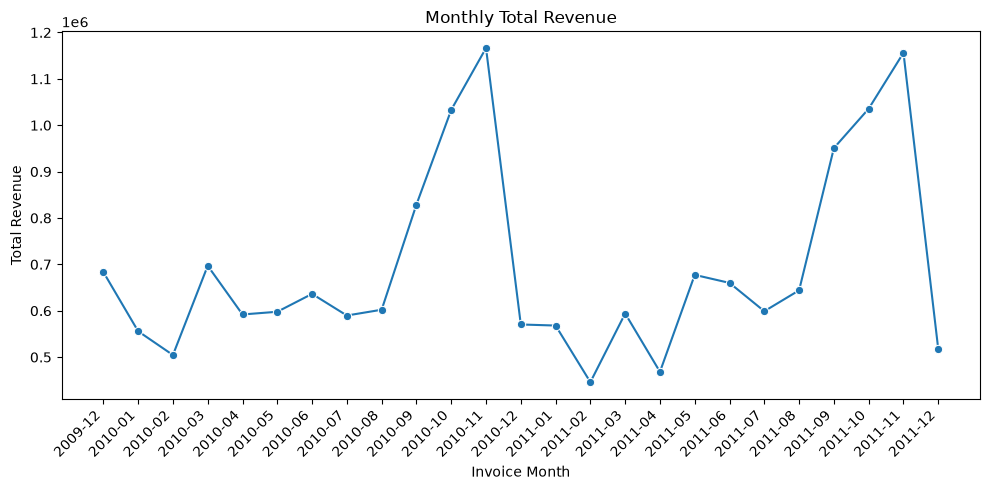

In [19]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales_summary, x="InvoiceMonth", y="TotalRevenue", marker="o")
plt.title("Monthly Total Revenue")
plt.xlabel("Invoice Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "monthly_revenue_trend.png", dpi=150)
plt.show()

**Interpretation:** Monthly revenue fluctuates across the period, with the highest month in November 2010 at about 1.17 million in revenue. Revenue also rises strongly in September to November 2011 before dropping in December 2011. The December 2011 month is incomplete because the data ends on December 9, 2011, so it should not be compared as a full month.

### Research Question 2: Which countries generate the highest revenue?

The table ranks countries by cleaned total revenue.

In [20]:
top_countries_revenue = (
    df_clean.groupby("Country", as_index=False)
    .agg(TotalRevenue=("TotalPrice", "sum"))
    .sort_values("TotalRevenue", ascending=False)
    .head(10)
)

top_countries_revenue.to_csv(tables_dir / "top_countries_revenue.csv", index=False)
top_countries_revenue

,Country,TotalRevenue
38,United Kingdom,1.438923e+07
10,EIRE,6.165705e+05
24,Netherlands,5.540381e+05
14,Germany,4.250197e+05
13,France,3.487690e+05
0,Australia,1.692835e+05
32,Spain,1.083325e+05
34,Switzerland,1.000619e+05
33,Sweden,9.151582e+04
9,Denmark,6.858069e+04


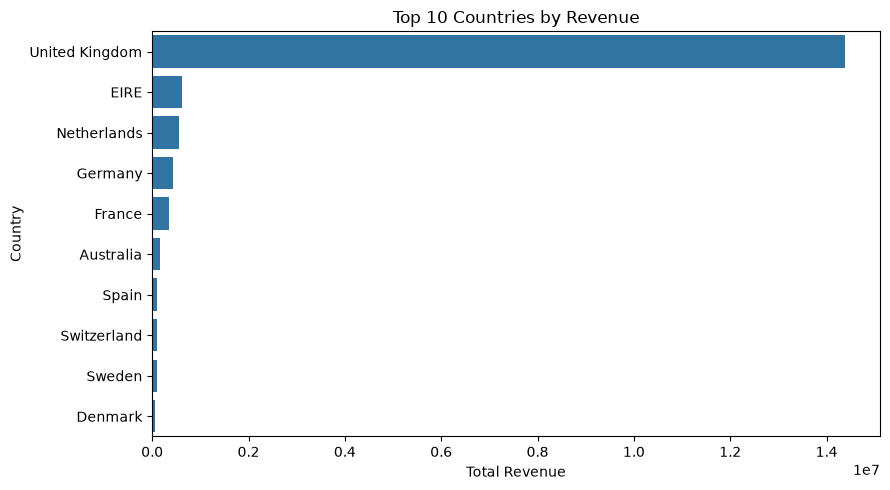

In [21]:
plt.figure(figsize=(9, 5))
sns.barplot(data=top_countries_revenue, x="TotalRevenue", y="Country")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(figures_dir / "top_countries_revenue.png", dpi=150)
plt.show()

**Interpretation:** The United Kingdom is by far the largest revenue source, generating about 14.39 million, or roughly 82.8% of cleaned revenue. EIRE, the Netherlands, Germany, and France form the next group, but each is much smaller than the UK. This concentration means country-level conclusions are heavily influenced by the UK market.

### Research Question 3: Which products generate the highest revenue?

The table ranks products by cleaned total revenue and includes StockCode, Description, Quantity, and TotalPrice.

In [22]:
top_products_revenue = (
    df_clean.groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Quantity=("Quantity", "sum"),
        TotalPrice=("TotalPrice", "sum"),
    )
    .sort_values("TotalPrice", ascending=False)
    .head(10)
)

top_products_revenue.to_csv(tables_dir / "top_products_revenue.csv", index=False)
top_products_revenue

,StockCode,Description,Quantity,TotalPrice
1862,22423,REGENCY CAKESTAND 3 TIER,24124,277656.25
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757,247048.01
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
5309,M,Manual,9384,151777.67
4725,85099B,JUMBO BAG RED RETROSPOT,74224,134307.44
5311,POST,POSTAGE,5235,124648.04
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,78234,124351.86
3627,47566,PARTY BUNTING,23460,103283.38
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
1449,22086,PAPER CHAIN KIT 50'S CHRISTMAS,28380,76598.18


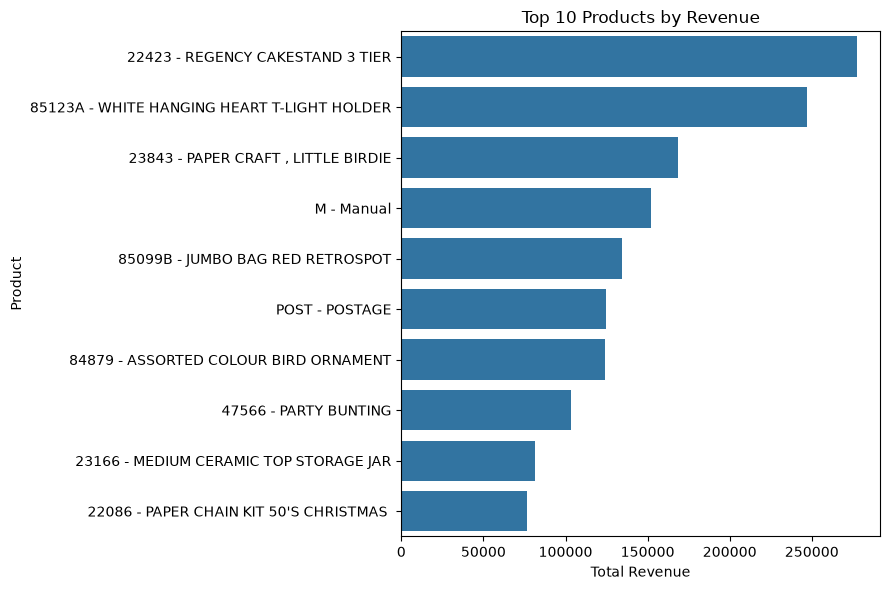

In [23]:
top_products_plot = top_products_revenue.copy()
top_products_plot["ProductLabel"] = (
    top_products_plot["StockCode"].astype(str) + " - " + top_products_plot["Description"].astype(str).str.slice(0, 45)
)

plt.figure(figsize=(9, 6))
sns.barplot(data=top_products_plot, x="TotalPrice", y="ProductLabel")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(figures_dir / "top_products_revenue.png", dpi=150)
plt.show()

**Interpretation:** REGENCY CAKESTAND 3 TIER is the top product by revenue at about 277.7 thousand, followed by WHITE HANGING HEART T-LIGHT HOLDER at about 247.0 thousand. A few non-standard lines such as Manual and Postage appear among top revenue items, so product-level interpretation should separate merchandise from service or adjustment lines in later work if needed.

### Research Question 4: What do the main numeric variables show about order behavior?

The summary and plots describe Quantity, UnitPrice, and TotalPrice in the cleaned transaction lines.

In [24]:
numeric_columns = ["Quantity", "UnitPrice", "TotalPrice"]
numeric_summary = df_clean[numeric_columns].describe().T.reset_index().rename(columns={"index": "Variable"})
numeric_summary.to_csv(tables_dir / "numeric_summary.csv", index=False)
numeric_summary

,Variable,count,mean,std,min,25%,50%,75%,max
0,Quantity,779425.0,13.489370,145.855814,1.000,2.00,6.00,12.00,80995.0
1,UnitPrice,779425.0,3.218488,29.676140,0.001,1.25,1.95,3.75,10953.5
2,TotalPrice,779425.0,22.291823,227.427075,0.001,4.95,12.48,19.80,168469.6


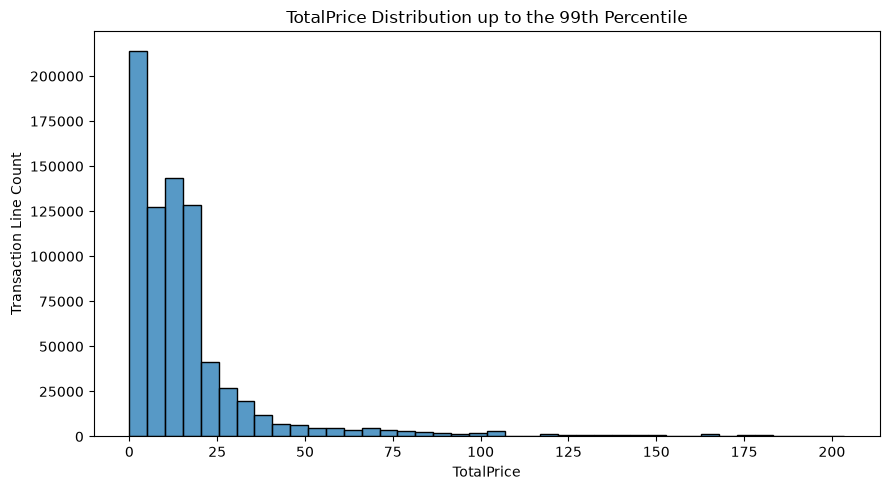

In [25]:
# Cap the histogram at the 99th percentile so a few very large lines do not compress the view.
totalprice_99th = df_clean["TotalPrice"].quantile(0.99)

plt.figure(figsize=(9, 5))
sns.histplot(df_clean.loc[df_clean["TotalPrice"] <= totalprice_99th, "TotalPrice"], bins=40)
plt.title("TotalPrice Distribution up to the 99th Percentile")
plt.xlabel("TotalPrice")
plt.ylabel("Transaction Line Count")
plt.tight_layout()
plt.savefig(figures_dir / "totalprice_distribution.png", dpi=150)
plt.show()

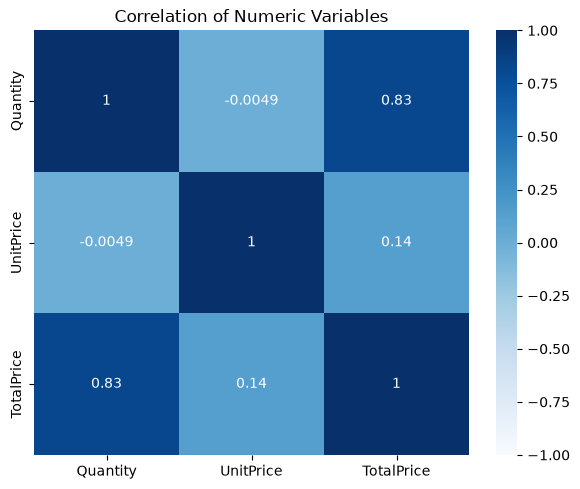

In [26]:
numeric_correlation = df_clean[numeric_columns].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_correlation, annot=True, cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation of Numeric Variables")
plt.tight_layout()
plt.savefig(figures_dir / "numeric_correlation_heatmap.png", dpi=150)
plt.show()

**Interpretation:** The median transaction-line TotalPrice is 12.48, while the mean is 22.29, showing a right-skewed distribution with a small number of large lines. Quantity and TotalPrice have a strong positive correlation of about 0.83, while UnitPrice has only a weak relationship with Quantity. The histogram is capped at the 99th percentile for readability because extreme values compress the main distribution.

### EDA Summary

- Research questions answered: monthly sales over time, top revenue countries, top revenue products, and numeric order behavior.
- Tables created: `monthly_sales_summary.csv`, `top_countries_revenue.csv`, `top_products_revenue.csv`, and `numeric_summary.csv`.
- Figures created: `monthly_revenue_trend.png`, `top_countries_revenue.png`, `top_products_revenue.png`, `totalprice_distribution.png`, and `numeric_correlation_heatmap.png`.
- Main findings: revenue peaks in November 2010; the UK dominates country revenue; the top product by revenue is REGENCY CAKESTAND 3 TIER; TotalPrice is strongly right-skewed and mostly driven by Quantity.

## 6. RFM Feature Engineering and Customer Segmentation

This section creates customer-level RFM features from the cleaned Online Retail II dataset and trains one simple K-Means clustering model for exploratory customer segmentation.


In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

cleaned_data_path = Path("data/processed/online_retail_cleaned.csv")
processed_data_dir = Path("data/processed")
tables_dir = Path("outputs/tables")
figures_dir = Path("outputs/figures")

processed_data_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

if not cleaned_data_path.exists():
    raise FileNotFoundError("Cleaned dataset is missing: data/processed/online_retail_cleaned.csv")

required_rfm_columns = ["CustomerID", "InvoiceNo", "InvoiceDate", "Quantity", "UnitPrice", "TotalPrice"]

if "df_clean" not in globals():
    df_clean = pd.read_csv(cleaned_data_path)
else:
    df_clean = df_clean.copy()

missing_rfm_columns = [column for column in required_rfm_columns if column not in df_clean.columns]
if missing_rfm_columns:
    raise ValueError(f"Missing required columns for RFM segmentation: {missing_rfm_columns}")

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")
df_clean["CustomerID"] = df_clean["CustomerID"].astype("string")
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype("string")
df_clean["Quantity"] = pd.to_numeric(df_clean["Quantity"], errors="coerce")
df_clean["UnitPrice"] = pd.to_numeric(df_clean["UnitPrice"], errors="coerce")
df_clean["TotalPrice"] = pd.to_numeric(df_clean["TotalPrice"], errors="coerce")

rfm_input_check = {
    "Rows": len(df_clean),
    "Columns": df_clean.shape[1],
    "Earliest invoice date": df_clean["InvoiceDate"].min(),
    "Latest invoice date": df_clean["InvoiceDate"].max(),
    "Required columns present": not missing_rfm_columns,
}
rfm_input_check


ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# Reference date = one day after the last transaction, so Recency is never zero.
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

# Aggregate transactions to one row per customer (Recency, Frequency, Monetary).
rfm = (
    df_clean.groupby("CustomerID", as_index=False)
    .agg(
        LatestPurchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),   # number of distinct orders
        Monetary=("TotalPrice", "sum"),        # total spend
    )
)
rfm["Recency"] = (reference_date - rfm["LatestPurchase"]).dt.days  # days since last order
rfm = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]].sort_values("CustomerID").reset_index(drop=True)

rfm.to_csv(tables_dir / "rfm_features.csv", index=False)
rfm

### Basic RFM Inspection

The checks below confirm the customer-level table shape, sample records, summary statistics, missing values, and duplicate customer identifiers before clustering.


In [ ]:
rfm.shape


In [ ]:
rfm.head()


In [ ]:
rfm.describe()


In [ ]:
rfm_missing_values = rfm.isna().sum().rename("MissingValues").reset_index().rename(columns={"index": "Column"})
rfm_duplicate_customer_ids = int(rfm["CustomerID"].duplicated().sum())

rfm_quality_check = {
    "Missing values by column": rfm_missing_values,
    "Duplicate CustomerID count": rfm_duplicate_customer_ids,
}
rfm_quality_check


### RFM Clustering Preparation

Only Recency, Frequency, and Monetary are used for clustering. The features are transformed with `log1p` to reduce skewness, then standardized so K-Means does not overweight variables with larger numeric scales.


In [ ]:
rfm_feature_columns = ["Recency", "Frequency", "Monetary"]
rfm_clustering_features = rfm[rfm_feature_columns].copy()

# log1p reduces the heavy right-skew; StandardScaler puts all three features on the same scale
# so K-Means (a distance-based method) does not overweight Monetary.
rfm_log_features = np.log1p(rfm_clustering_features)

scaler = StandardScaler()
rfm_scaled_features = scaler.fit_transform(rfm_log_features)

pd.DataFrame(rfm_scaled_features, columns=rfm_feature_columns).head()

In [ ]:
# Try k = 2..6 and record inertia (elbow) and silhouette score to choose a defensible k.
k_values = range(2, 7)
clustering_metric_rows = []

for k in k_values:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_model.fit_predict(rfm_scaled_features)
    clustering_metric_rows.append(
        {
            "k": k,
            "Inertia": kmeans_model.inertia_,
            "SilhouetteScore": silhouette_score(rfm_scaled_features, cluster_labels),
        }
    )

clustering_metrics = pd.DataFrame(clustering_metric_rows)
clustering_metrics.to_csv(tables_dir / "clustering_metrics.csv", index=False)
clustering_metrics

In [ ]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=clustering_metrics, x="k", y="Inertia", marker="o")
plt.title("K-Means Elbow Plot")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig(figures_dir / "kmeans_elbow_plot.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
sns.lineplot(data=clustering_metrics, x="k", y="SilhouetteScore", marker="o")
plt.title("K-Means Silhouette Scores")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig(figures_dir / "kmeans_silhouette_scores.png", dpi=150)
plt.show()


In [ ]:
selected_k = 4
selected_k_reason = (
    "Selected k=4 because inertia continues to drop meaningfully through four clusters, "
    "and the silhouette score improves from k=3 to k=4. k=2 has the highest silhouette "
    "but is too broad for actionable RFM segment interpretation."
)
selected_k_reason


### Final K-Means Model and Cluster Summary

The final model uses the selected four-cluster solution with a fixed random seed for reproducibility.


In [ ]:
# Fit the final model with the selected k and assign a cluster to every customer.
final_kmeans = KMeans(n_clusters=selected_k, random_state=42, n_init=10)
rfm["Cluster"] = final_kmeans.fit_predict(rfm_scaled_features)

# Profile each cluster with its mean R, F, M and customer count.
cluster_summary = (
    rfm.groupby("Cluster", as_index=False)
    .agg(
        CustomerCount=("CustomerID", "count"),
        MeanRecency=("Recency", "mean"),
        MeanFrequency=("Frequency", "mean"),
        MeanMonetary=("Monetary", "mean"),
    )
)

# Attach a human-readable label to each cluster from its RFM profile.
summary_indexed = cluster_summary.set_index("Cluster")
cluster_label_map = {}
high_value_cluster = int(summary_indexed["MeanMonetary"].idxmax())          # highest spend
inactive_cluster = int(
    summary_indexed.sort_values(["MeanRecency", "MeanMonetary"], ascending=[False, True]).index[0]
)                                                                            # oldest + lowest spend
cluster_label_map[high_value_cluster] = "High-value loyal customers"
cluster_label_map[inactive_cluster] = "Inactive low-value customers"

# The most recent of the remaining clusters is the "recent moderate" group.
remaining_clusters = [cluster for cluster in summary_indexed.index if cluster not in cluster_label_map]
if remaining_clusters:
    recent_cluster = int(summary_indexed.loc[remaining_clusters, "MeanRecency"].idxmin())
    cluster_label_map[recent_cluster] = "Recent moderate customers"

# Label any cluster still unlabeled from its recency / frequency / spend profile.
for cluster in summary_indexed.index:
    if cluster not in cluster_label_map:
        row = summary_indexed.loc[cluster]
        if row["MeanRecency"] > rfm["Recency"].mean() and row["MeanMonetary"] > rfm["Monetary"].median():
            cluster_label_map[int(cluster)] = "Lapsed higher-spend customers"
        elif row["MeanFrequency"] <= rfm["Frequency"].median():
            cluster_label_map[int(cluster)] = "Low-frequency customers"
        else:
            cluster_label_map[int(cluster)] = "Steady mid-value customers"

rfm["SegmentLabel"] = rfm["Cluster"].map(cluster_label_map)
cluster_summary["SegmentLabel"] = cluster_summary["Cluster"].map(cluster_label_map)
cluster_summary = cluster_summary[
    ["Cluster", "SegmentLabel", "CustomerCount", "MeanRecency", "MeanFrequency", "MeanMonetary"]
].round({"MeanRecency": 2, "MeanFrequency": 2, "MeanMonetary": 2})

rfm.to_csv(processed_data_dir / "customer_segments.csv", index=False)
cluster_summary.to_csv(tables_dir / "cluster_summary.csv", index=False)
cluster_summary

### Cluster Visualizations

The plots below show how the four customer segments separate across RFM dimensions.


In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster", palette="tab10", alpha=0.65, s=35)
plt.yscale("log")
plt.title("Customer Clusters: Recency vs Monetary")
plt.xlabel("Recency (days since latest purchase)")
plt.ylabel("Monetary value (log scale)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig(figures_dir / "rfm_recency_monetary_clusters.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette="tab10", alpha=0.65, s=35)
plt.xscale("log")
plt.yscale("log")
plt.title("Customer Clusters: Frequency vs Monetary")
plt.xlabel("Frequency (unique invoices, log scale)")
plt.ylabel("Monetary value (log scale)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig(figures_dir / "rfm_frequency_monetary_clusters.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_summary, x="Cluster", y="MeanMonetary", hue="SegmentLabel", dodge=False, palette="tab10")
plt.title("Mean Monetary Value by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Monetary value")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(figures_dir / "cluster_monetary_barplot.png", dpi=150)
plt.show()


### RFM Cluster Interpretation

RFM means Recency, Frequency, and Monetary value. Recency measures how many days have passed since a customer's latest purchase, Frequency counts unique invoices, and Monetary value sums each customer's total spend.

Clustering is suitable here because the project needs exploratory customer groups based on purchasing behavior, not a supervised prediction target. K-Means provides a simple, defensible baseline using only the three RFM features.

The selected solution uses `k=4`. Inertia continues to improve through four clusters, and the silhouette score improves from `k=3` to `k=4`; although `k=2` has the highest silhouette score, it is too broad for useful customer segmentation.

- Cluster 2, High-value loyal customers: 1,196 customers with very recent purchases, the highest frequency, and the highest monetary value. This is the strongest customer group by value and repeat activity.
- Cluster 1, Recent moderate customers: 1,250 customers with recent purchases but much lower frequency and spend than the loyal segment. This group looks active but not yet deeply engaged.
- Cluster 3, Lapsed higher-spend customers: 1,459 customers with older purchase recency but stronger spend and frequency than the low-value group. This segment may represent customers worth reactivation.
- Cluster 0, Inactive low-value customers: 1,973 customers with the oldest average recency, lowest frequency, and lowest monetary value. This is the weakest segment by recent engagement and value.

These clusters are exploratory and do not prove that any RFM pattern causes later customer behavior.


### Segmentation Summary

- Customers segmented: 5,878
- Selected number of clusters: 4
- Files created: `outputs/tables/rfm_features.csv`, `outputs/tables/clustering_metrics.csv`, `outputs/tables/cluster_summary.csv`, `data/processed/customer_segments.csv`, and five clustering figures in `outputs/figures/`.
- Main segment findings: the model separates high-value loyal customers, recent moderate customers, lapsed higher-spend customers, and inactive low-value customers.


## 7. Results Consolidation and Interpretation

This section consolidates the EDA and RFM clustering outputs into concise interpretation tables (project KPIs, research-question findings, and segment interpretations) and a final segment-count figure.


In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cleaned_data_path = Path("data/processed/online_retail_cleaned.csv")
customer_segments_path = Path("data/processed/customer_segments.csv")
tables_dir = Path("outputs/tables")
figures_dir = Path("outputs/figures")

required_inputs = {
    "Cleaned dataset": cleaned_data_path,
    "Customer segments": customer_segments_path,
    "Monthly sales summary": tables_dir / "monthly_sales_summary.csv",
    "Top countries revenue": tables_dir / "top_countries_revenue.csv",
    "Top products revenue": tables_dir / "top_products_revenue.csv",
    "Numeric summary": tables_dir / "numeric_summary.csv",
    "Cluster summary": tables_dir / "cluster_summary.csv",
}

missing_inputs = [str(path) for path in required_inputs.values() if not path.exists()]
if missing_inputs:
    raise FileNotFoundError(f"Missing required input files: {missing_inputs}")

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

df_clean = pd.read_csv(cleaned_data_path, parse_dates=["InvoiceDate"])
customer_segments = pd.read_csv(customer_segments_path)
monthly_sales_summary = pd.read_csv(tables_dir / "monthly_sales_summary.csv")
top_countries_revenue = pd.read_csv(tables_dir / "top_countries_revenue.csv")
top_products_revenue = pd.read_csv(tables_dir / "top_products_revenue.csv")
numeric_summary = pd.read_csv(tables_dir / "numeric_summary.csv")
cluster_summary = pd.read_csv(tables_dir / "cluster_summary.csv")

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")

loaded_inputs = {
    "Cleaned rows": len(df_clean),
    "Segmented customers": len(customer_segments),
    "Cluster summary rows": len(cluster_summary),
    "Date range": f"{df_clean['InvoiceDate'].min().date()} to {df_clean['InvoiceDate'].max().date()}",
}
loaded_inputs

### Project KPI Summary

The table below summarizes the cleaned transaction-level dataset at the project level.


In [ ]:
invoice_revenue = df_clean.groupby("InvoiceNo", as_index=False)["TotalPrice"].sum()

total_revenue = df_clean["TotalPrice"].sum()
unique_invoices = df_clean["InvoiceNo"].nunique()
project_kpi_summary = pd.DataFrame(
    [
        {"Metric": "Total cleaned transactions", "Value": len(df_clean)},
        {"Metric": "Number of unique customers", "Value": df_clean["CustomerID"].nunique()},
        {"Metric": "Number of unique invoices", "Value": unique_invoices},
        {"Metric": "Number of unique products", "Value": df_clean["StockCode"].nunique()},
        {"Metric": "Number of countries", "Value": df_clean["Country"].nunique()},
        {"Metric": "Total revenue", "Value": round(total_revenue, 2)},
        {"Metric": "Average invoice revenue", "Value": round(invoice_revenue["TotalPrice"].mean(), 2)},
        {
            "Metric": "Date range",
            "Value": f"{df_clean['InvoiceDate'].min().date()} to {df_clean['InvoiceDate'].max().date()}",
        },
    ]
)

project_kpi_summary.to_csv(tables_dir / "project_kpi_summary.csv", index=False)
project_kpi_summary


### Research Question Summary

This table summarizes the EDA and RFM findings, with one row per research question.


In [ ]:
monthly_peak = monthly_sales_summary.loc[monthly_sales_summary["TotalRevenue"].idxmax()]
top_country = top_countries_revenue.iloc[0]
top_product = top_products_revenue.iloc[0]
totalprice_summary = numeric_summary.loc[numeric_summary["Variable"] == "TotalPrice"].iloc[0]
high_value_segment = cluster_summary.loc[cluster_summary["MeanMonetary"].idxmax()]
largest_segment = cluster_summary.loc[cluster_summary["CustomerCount"].idxmax()]

research_question_summary = pd.DataFrame(
    [
        {
            "Research Question": "How do total sales change over time?",
            "Main Evidence": f"Monthly revenue peaks in {monthly_peak['InvoiceMonth']} at {monthly_peak['TotalRevenue']:,.2f}.",
            "Main Finding": "Sales are seasonal, with the strongest revenue period occurring late in the observed period.",
            "Limitation": "The monthly pattern is historical and may reflect promotions, holidays, or missing business context.",
        },
        {
            "Research Question": "Which countries generate the highest revenue?",
            "Main Evidence": f"{top_country['Country']} is the top country with {top_country['TotalRevenue']:,.2f} in revenue.",
            "Main Finding": "Revenue is heavily concentrated in the leading country market.",
            "Limitation": "Country revenue does not account for market size, margin, or customer acquisition cost.",
        },
        {
            "Research Question": "Which products generate the highest revenue?",
            "Main Evidence": f"{top_product['Description']} is the top product with {top_product['TotalPrice']:,.2f} in revenue.",
            "Main Finding": "A small group of products and service-like lines account for a large share of revenue.",
            "Limitation": "Product descriptions may contain noise and some top lines may not represent standard merchandise.",
        },
        {
            "Research Question": "What do numeric order variables show about order behavior?",
            "Main Evidence": f"TotalPrice mean is {totalprice_summary['mean']:.2f}, while the median is {totalprice_summary['50%']:.2f}.",
            "Main Finding": "Order-line value is strongly right-skewed, with many small purchases and a few very large lines.",
            "Limitation": "Summary statistics are sensitive to extreme values in quantity, unit price, and line totals.",
        },
        {
            "Research Question": "What customer segments are found using RFM clustering?",
            "Main Evidence": f"Four RFM clusters were identified; the highest-value segment has {int(high_value_segment['CustomerCount']):,} customers and mean monetary value of {high_value_segment['MeanMonetary']:,.2f}.",
            "Main Finding": f"The segments distinguish high-value loyal, recent moderate, lapsed higher-spend, and inactive low-value customers; the largest segment is {largest_segment['SegmentLabel']}.",
            "Limitation": "Clustering is exploratory and does not prove causality or future customer behavior.",
        },
    ]
)

research_question_summary.to_csv(tables_dir / "research_question_summary.csv", index=False)
research_question_summary


### Customer Segment Interpretation

The segment interpretation table uses the cluster summary and adds a concise business interpretation for each cluster.


In [ ]:
segment_interpretation = cluster_summary.copy()

if "Segment_Label" not in segment_interpretation.columns:
    if "SegmentLabel" in segment_interpretation.columns:
        segment_interpretation["Segment_Label"] = segment_interpretation["SegmentLabel"]
    else:
        segment_interpretation["Segment_Label"] = "Cluster " + segment_interpretation["Cluster"].astype(str)

interpretation_map = {
    "High-value loyal customers": "Very recent buyers with the highest frequency and spend; prioritize retention, loyalty benefits, and premium offers.",
    "Recent moderate customers": "Recently active customers with moderate frequency and spend; nurture them toward repeat purchasing.",
    "Lapsed higher-spend customers": "Customers with meaningful past value but weaker recent activity; good candidates for reactivation campaigns.",
    "Inactive low-value customers": "Older, low-frequency, low-spend customers; use low-cost win-back tactics and avoid over-investing.",
}

segment_interpretation["Interpretation"] = segment_interpretation["Segment_Label"].map(interpretation_map)
segment_interpretation["Interpretation"] = segment_interpretation["Interpretation"].fillna(
    segment_interpretation.apply(
        lambda row: (
            f"Cluster {row['Cluster']} has mean recency {row['MeanRecency']:.2f}, "
            f"frequency {row['MeanFrequency']:.2f}, and monetary value {row['MeanMonetary']:.2f}."
        ),
        axis=1,
    )
)

segment_interpretation = segment_interpretation[
    [
        "Cluster",
        "Segment_Label",
        "CustomerCount",
        "MeanRecency",
        "MeanFrequency",
        "MeanMonetary",
        "Interpretation",
    ]
]
segment_interpretation.to_csv(tables_dir / "segment_interpretation.csv", index=False)
segment_interpretation


### Final Segment Count Visualization

This final combined view summarizes how many customers fall into each RFM segment.


In [ ]:
segment_count_plot = segment_interpretation.sort_values("CustomerCount", ascending=True)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=segment_count_plot,
    x="CustomerCount",
    y="Segment_Label",
    hue="Segment_Label",
    dodge=False,
    palette="tab10",
    legend=False,
)
plt.title("Customer Count by Segment")
plt.xlabel("Customer count")
plt.ylabel("Segment")
plt.tight_layout()
plt.savefig(figures_dir / "customer_segments_count.png", dpi=150)
plt.show()


### Consolidated Findings Interpretation

The cleaned Online Retail II data contains 779,425 transaction lines from 5,878 customers over the period from 2009-12-01 to 2011-12-09. Revenue is seasonal, with the highest monthly revenue occurring in November 2010. The United Kingdom generates the largest share of revenue, so the business is strongly concentrated in one country market. Product revenue is also concentrated, led by REGENCY CAKESTAND 3 TIER, while product descriptions include some noisy or service-like lines such as Manual and Postage. Numeric order variables are right-skewed, meaning most order lines are small but a few very large purchases strongly influence totals.

The RFM segmentation identifies four customer groups: high-value loyal customers, recent moderate customers, lapsed higher-spend customers, and inactive low-value customers. High-value loyal customers are the strongest segment because they buy recently, frequently, and at high monetary value. Recent moderate customers are still active but have lower spend and frequency, making them suitable for nurturing and repeat-purchase campaigns. Lapsed higher-spend customers have meaningful historical value but weaker recent activity, so reactivation may be worthwhile. Inactive low-value customers are the largest segment and have low recent engagement, frequency, and spend.

For an e-commerce business, these findings can guide campaign prioritization, retention planning, reactivation offers, and merchandising focus. The key limitations are that the analysis is based on historical transaction data, clustering is exploratory, removed cancellations and missing CustomerID records may affect conclusions, and product descriptions may contain noise.


### Results Summary

- Consolidated tables created: `project_kpi_summary.csv`, `research_question_summary.csv`, and `segment_interpretation.csv`.
- Final figure created: `customer_segments_count.png`.
- The cleaned dataset, EDA outputs, RFM segmentation, and consolidated findings together answer all five research questions defined at the start of the notebook.
